In [46]:
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice, TriangleLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from fast_boolean_analysis import (
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    FourierSeries,
    fourier_expand,
)

from lattice_boolean_analysis import (
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
    LBFFromSpinSystem,
)

from loguru import logger

from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse
import sys
from typing import NamedTuple
from utils import read_jsonl_to_df

from parity import popcount
from dataclasses import dataclass, astuple

ground_state_cache_dir = Path("groundstates")

outdir = Path("experiments/boolean-analysis-complexity")
outdir.mkdir(exist_ok=True, parents=True)

outfile = outdir / "complexity.jsonl"




def get_score_column(df: pd.DataFrame, scorer: str) -> list:
    return [
        row["series"].truncate(keep_largest_n(row["terms"])).prediction_score(scorer=scorer)
        for _, row in (df.iterrows())
    ]

logger.remove()
logger.add(Path("boolean-analysis-complexity.ipynb.log", level="DEBUG", colorize=True))

3

In [47]:
%matplotlib inline

In [48]:
name_to_lat_and_sym = {
    lat_and_sym[0].get_cache_id(): lat_and_sym
    for lat_and_sym in [
        (KagomeLattice(width=3, height=3), False),
        (KagomeLattice(width=2, height=2), False),
    ]
}

name_to_signal_kind = {
    signal.name: signal for signal in [AmplitudeMedianBinSignalKind(), SignSignalKind()]
}


In [49]:
df = read_jsonl_to_df(outfile)

In [50]:
df

,lattice_name,J2,signal_kind,success,terms,target_score,target_scorer,sign_overlap,accuracy,f1
0,KagomeLattice2x2,0.0,sign,True,1,0.8,f1,1.000000,1.000000,1.000000
1,KagomeLattice2x2,0.0,amplitude_median_bin,True,23,0.8,f1,0.306630,0.814935,0.812775
2,KagomeLattice2x2,0.1,sign,True,1,0.8,f1,1.000000,1.000000,1.000000
3,KagomeLattice2x2,0.1,amplitude_median_bin,True,25,0.8,f1,0.378270,0.794372,0.845966
4,KagomeLattice2x2,0.2,sign,True,1,0.8,f1,1.000000,1.000000,1.000000
5,KagomeLattice2x2,0.2,amplitude_median_bin,True,25,0.8,f1,0.376859,0.835498,0.831638
6,KagomeLattice2x2,0.3,sign,True,1,0.8,f1,1.000000,0.991342,0.991150
7,KagomeLattice2x2,0.3,amplitude_median_bin,True,25,0.8,f1,0.369781,0.829004,0.833713
8,KagomeLattice2x2,0.4,sign,True,1,0.8,f1,0.999999,0.991342,0.991150
9,KagomeLattice2x2,0.4,amplitude_median_bin,True,25,0.8,f1,0.349329,0.837662,0.831461


In [27]:
df_temp = pd.DataFrame([[1, 2], [3, 4]], columns=["a", "b"])
df_temp['c'] = None
for i, row in df_temp.iterrows():
    df_temp.loc[i, 'c'] = row['a'] + row['b']
df_temp

,a,b,c
0,1,2,3
1,3,4,7


In [35]:
max_keep_terms = 10
df['largest_terms'] = None
df['largest_coeffs'] = None

for i, row in df.iterrows():
    lattice, use_symmetries = name_to_lat_and_sym[row["lattice_name"]]
    J2 = row["J2"]
    signal_kind = name_to_signal_kind[row["signal_kind"]]
    print(f"Processing {i} {row['lattice_name']} {row['J2']} {row['signal_kind']}")
    system = HeisenbergJ1J2(
            lattice=lattice,
            J1=1,
            J2=J2,
            use_symmetries=use_symmetries,
            spin_inversion=1 if use_symmetries else None,
            ground_state_cache_dir=ground_state_cache_dir,
        )
    series = fourier_expand(LBFFromSpinSystem(system=system, eigenstate=0, kind=signal_kind))
    df.loc[i, "hamming_weight"] = total_hamming_weight(series, row["terms"])
    df.loc[i, "number_spins"] = lattice.number_spins
    
    reprs = series.signal.lattice.get_fourier_repr().reprs
    coeffs = series.coeffs
    idxs, coeffs = get_abslargest_terms(coeffs[reprs],min(max_keep_terms, row["terms"]))
    subsets = reprs[idxs]
    
    df.at[i, "largest_terms"] = subsets.tolist()
    df.at[i, "largest_coeffs"] = coeffs.tolist()

Processing 0 KagomeLattice2x2 0.0 sign
Processing 1 KagomeLattice2x2 0.0 amplitude_median_bin
Processing 2 KagomeLattice2x2 0.1 sign
Processing 3 KagomeLattice2x2 0.1 amplitude_median_bin
Processing 4 KagomeLattice2x2 0.2 sign
Processing 5 KagomeLattice2x2 0.2 amplitude_median_bin
Processing 6 KagomeLattice2x2 0.3 sign
Processing 7 KagomeLattice2x2 0.3 amplitude_median_bin
Processing 8 KagomeLattice2x2 0.4 sign
Processing 9 KagomeLattice2x2 0.4 amplitude_median_bin
Processing 10 KagomeLattice2x2 0.5 sign
Processing 11 KagomeLattice2x2 0.5 amplitude_median_bin
Processing 12 KagomeLattice2x2 0.6 sign
Processing 13 KagomeLattice2x2 0.6 amplitude_median_bin
Processing 14 KagomeLattice2x2 0.7 sign
Processing 15 KagomeLattice2x2 0.7 amplitude_median_bin
Processing 16 KagomeLattice2x2 0.8 sign
Processing 17 KagomeLattice2x2 0.8 amplitude_median_bin
Processing 18 KagomeLattice2x2 0.9 sign
Processing 19 KagomeLattice2x2 0.9 amplitude_median_bin
Processing 20 KagomeLattice2x2 1.0 sign
Processing

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Processing 23 KagomeLattice3x3 0.0 amplitude_median_bin
Processing 24 KagomeLattice3x3 0.1 sign
Processing 25 KagomeLattice3x3 0.1 amplitude_median_bin
Processing 26 KagomeLattice3x3 0.2 sign
Processing 27 KagomeLattice3x3 0.2 amplitude_median_bin
Processing 28 KagomeLattice3x3 0.3 sign
Processing 29 KagomeLattice3x3 0.3 amplitude_median_bin
Processing 30 KagomeLattice3x3 0.4 sign
Processing 31 KagomeLattice3x3 0.4 amplitude_median_bin
Processing 32 KagomeLattice3x3 0.5 sign
Processing 33 KagomeLattice3x3 0.5 amplitude_median_bin
Processing 34 KagomeLattice3x3 0.6 sign
Processing 35 KagomeLattice3x3 0.6 amplitude_median_bin
Processing 36 KagomeLattice3x3 0.7 sign
Processing 37 KagomeLattice3x3 0.7 amplitude_median_bin
Processing 38 KagomeLattice3x3 0.8 sign
Processing 39 KagomeLattice3x3 0.8 amplitude_median_bin
Processing 40 KagomeLattice3x3 0.9 sign
Processing 41 KagomeLattice3x3 0.9 amplitude_median_bin
Processing 42 KagomeLattice3x3 1.0 sign
Processing 43 KagomeLattice3x3 1.0 ampli

In [36]:
series_df = df.assign(
    mean_hw=lambda df: df["hamming_weight"] / df["terms"],
).set_index(["lattice_name", "J2", "signal_kind"])


In [37]:
series_df.query('success == False')

,,,success,terms,target_score,target_scorer,sign_overlap,accuracy,f1,hamming_weight,number_spins,largest_terms,largest_coeffs,mean_hw
lattice_name,J2,signal_kind,,,,,,,,,,,,


In [39]:
np.log2(series_df.query('lattice_name.str.startswith("Kagome")').groupby('number_spins')['terms'].max())

number_spins
12.0     5.954196
27.0    18.187342
Name: terms, dtype: float64

In [63]:
%matplotlib inline

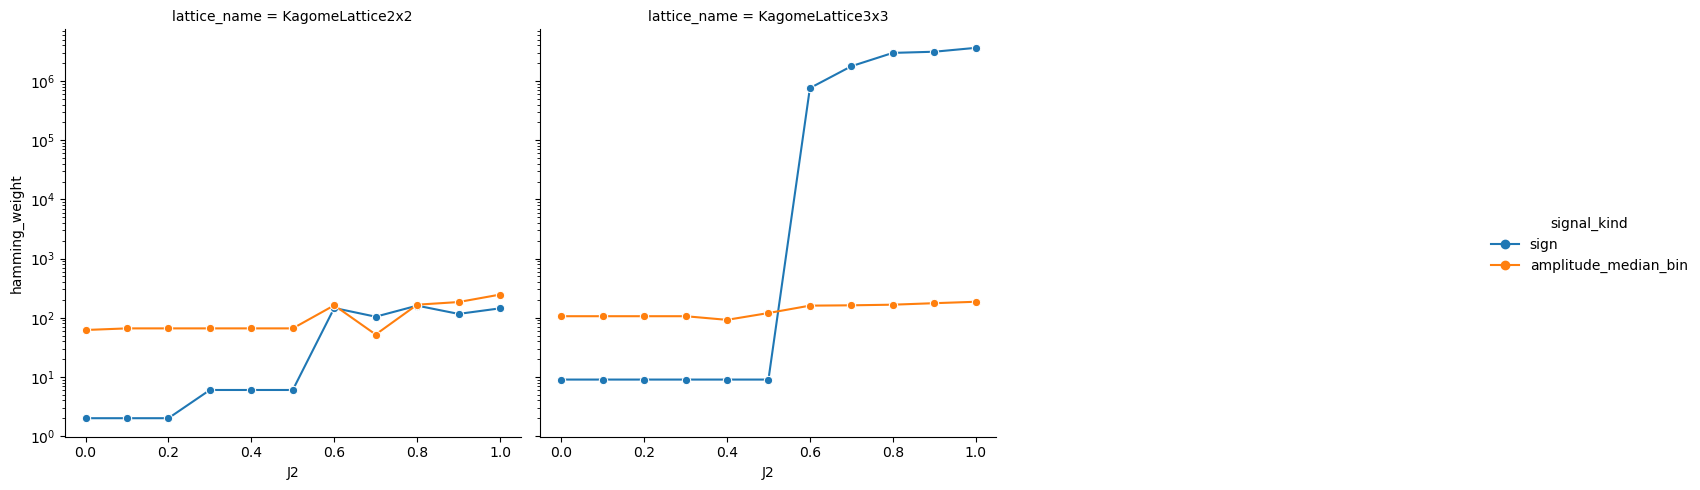

In [40]:
sns.relplot(
    series_df.reset_index(),
    x="J2",
    y="hamming_weight",
    hue="signal_kind",
    col="lattice_name",
    col_wrap=3,
    kind="line",
    # markers=True,
    style="signal_kind",
    dashes=False,
    markers=["o", "o"],
    # make y axis independent
    # facet_kws=dict(sharey=False),
).set(yscale="log")


[None]

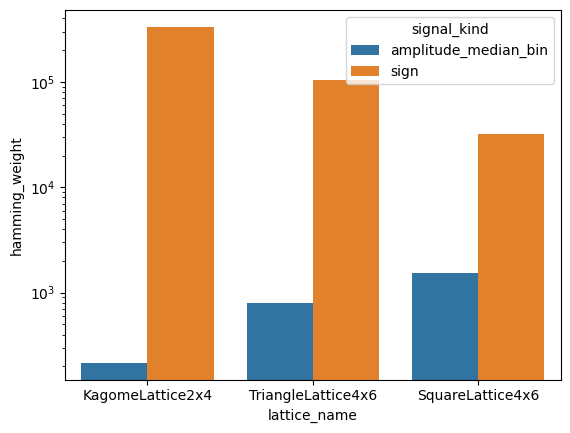

In [79]:
sns.barplot(series_df.query("number_spins == 24").reset_index().groupby(["lattice_name", "signal_kind"])[
    ["terms", "hamming_weight"]
].max().sort_values('hamming_weight').reset_index(), x='lattice_name', y='hamming_weight', hue='signal_kind').set(yscale='log')


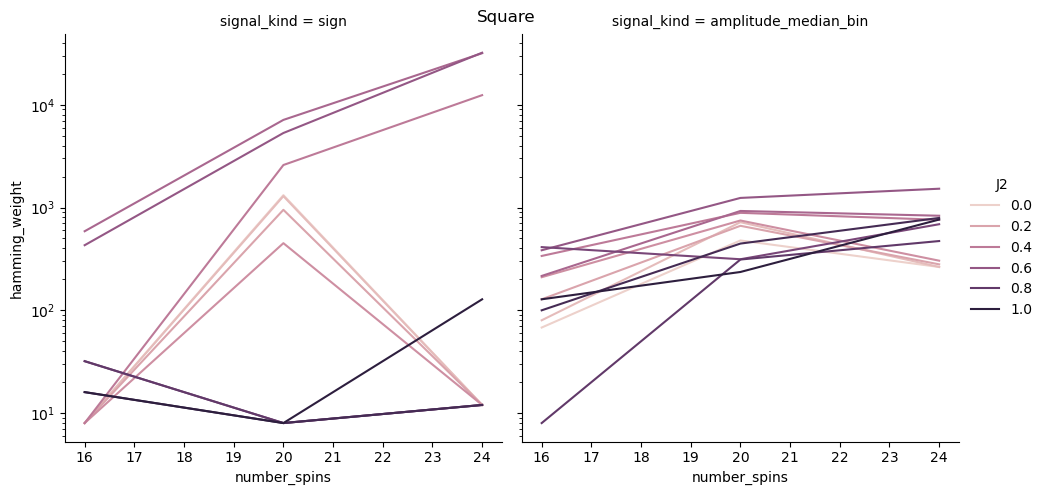

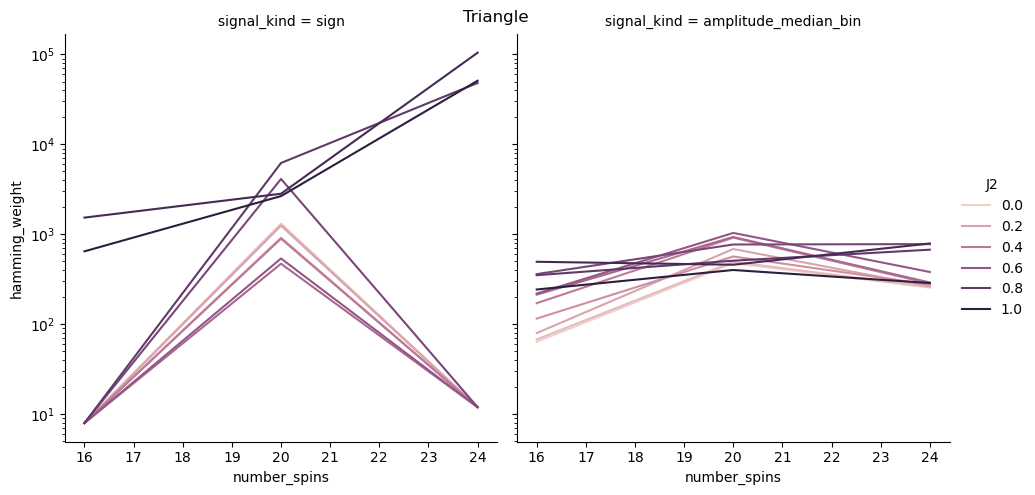

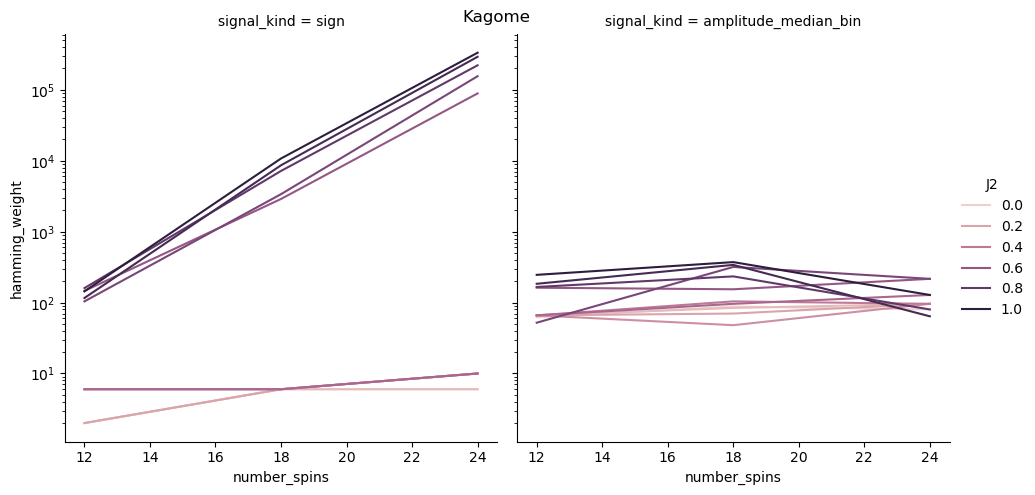

In [89]:
for lat in ['Square', 'Triangle', 'Kagome']:
    
    plot = sns.relplot(
        series_df.reset_index().query('lattice_name.str.startswith(@lat)'),
        x="number_spins",
        y="hamming_weight",
        col="signal_kind",
        hue="J2",
        kind="line",
        markers=True,
    ).set(yscale="log")
    plot.fig.suptitle(lat)


In [43]:
def plot_subsets(subsets, titles, lat: SpinLattice):
    fig, axes = plt.subplots(1, len(subsets), figsize=(len(subsets) * 3, 3), squeeze=False)
    for ax, subset, title in zip(axes[0], subsets, titles):
        lat.plot(spins=subset, ax=ax)
        ax.axis("off")
        ax.set_title(title)
    return fig


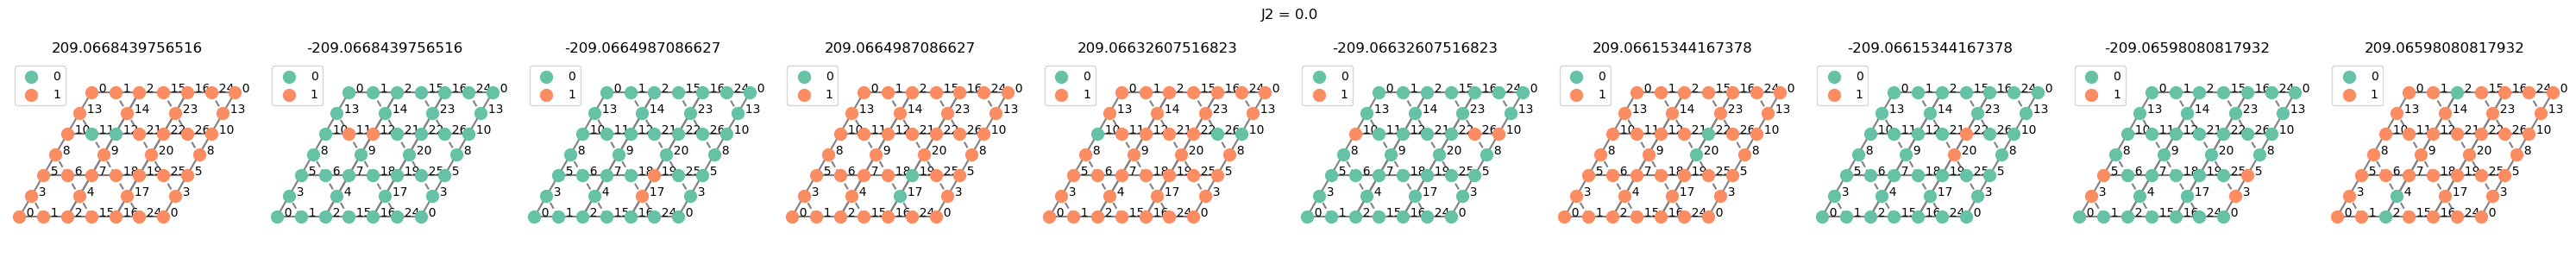

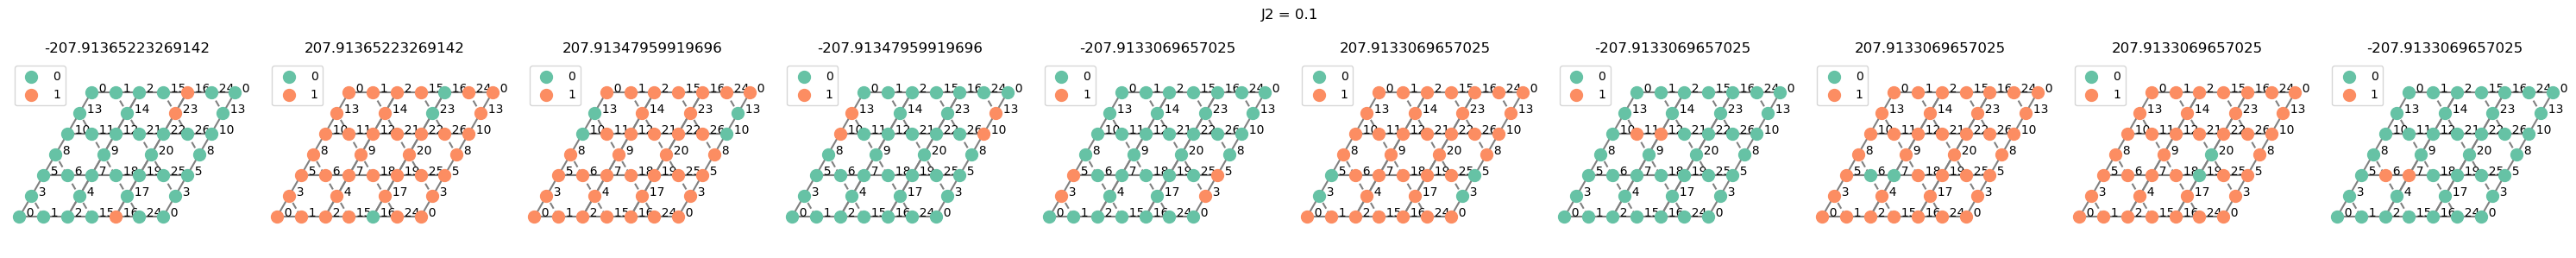

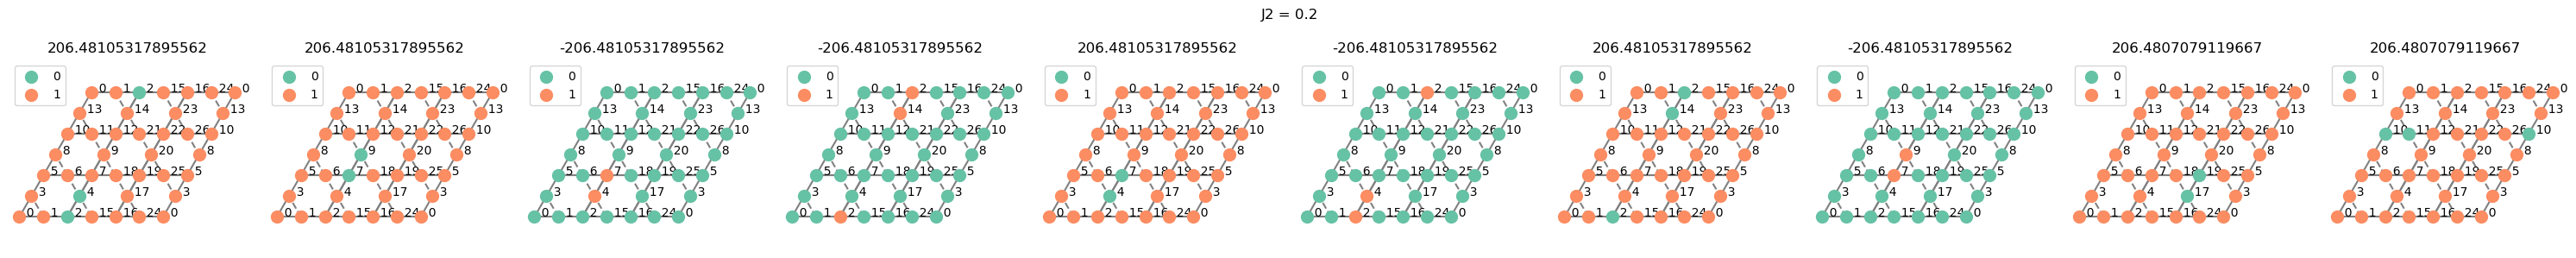

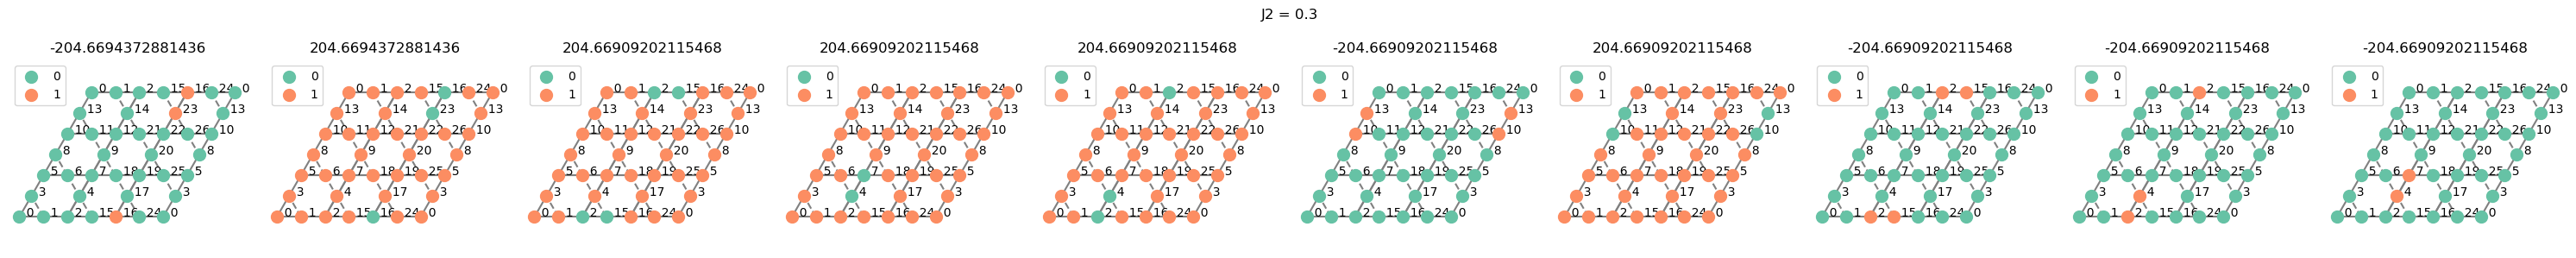

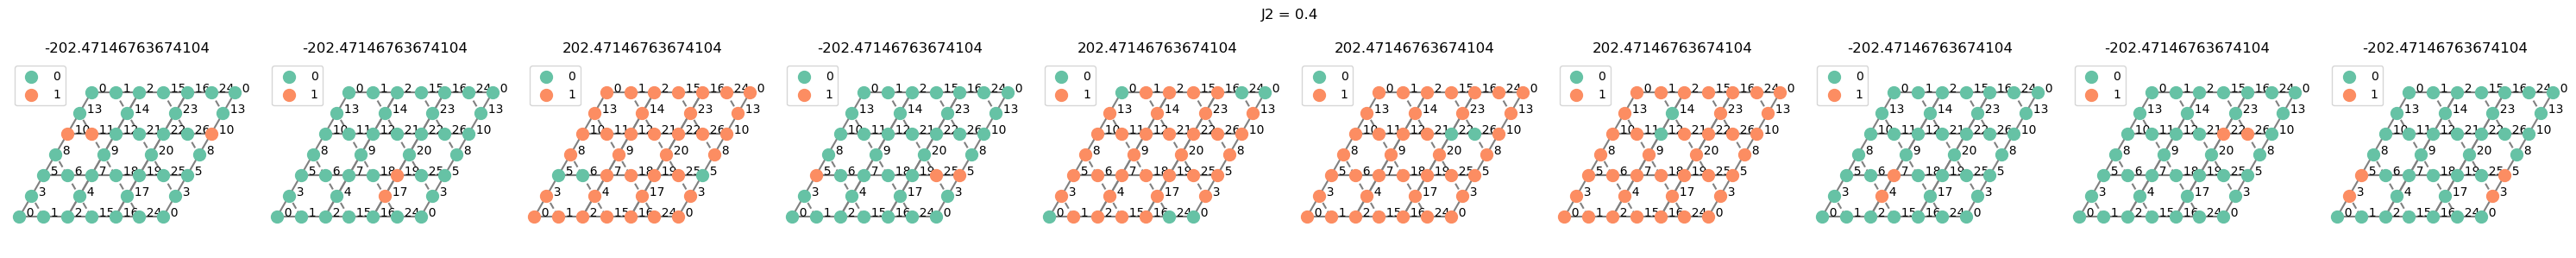

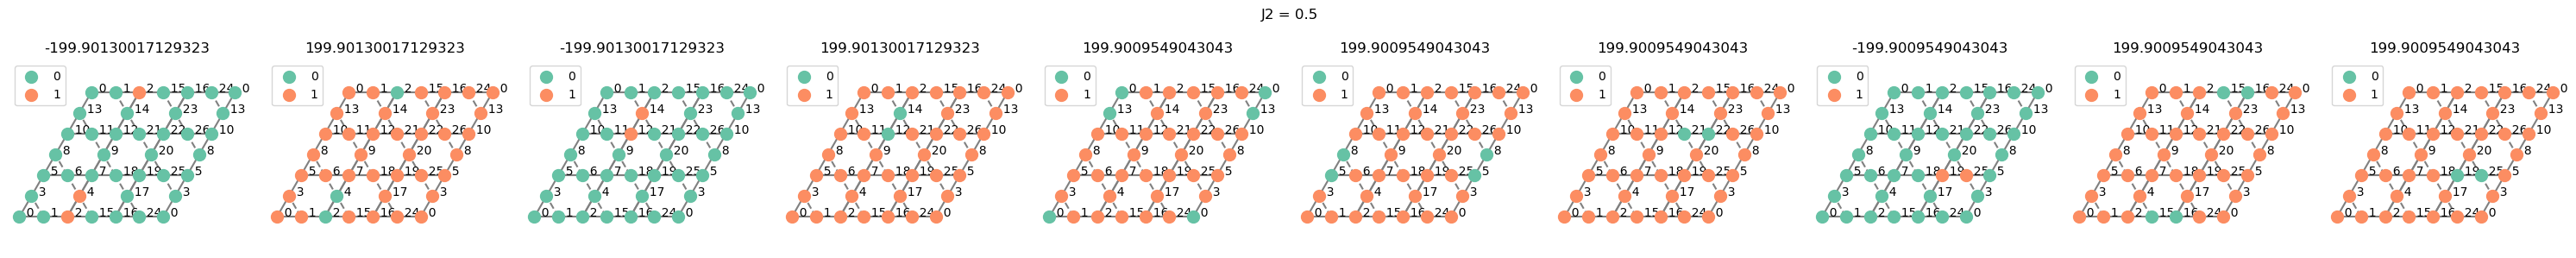

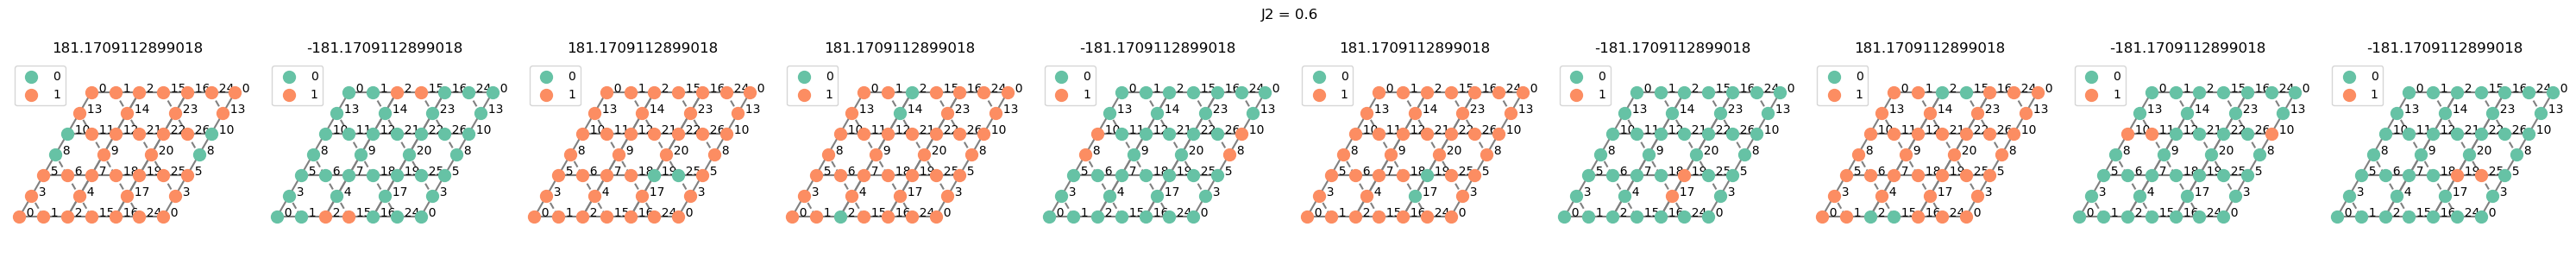

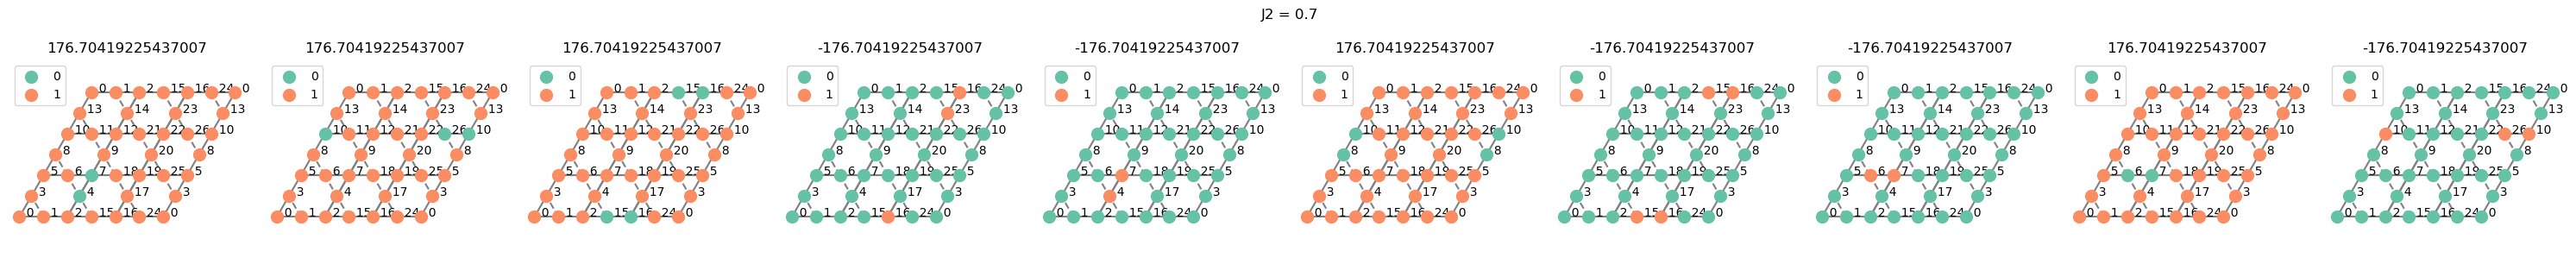

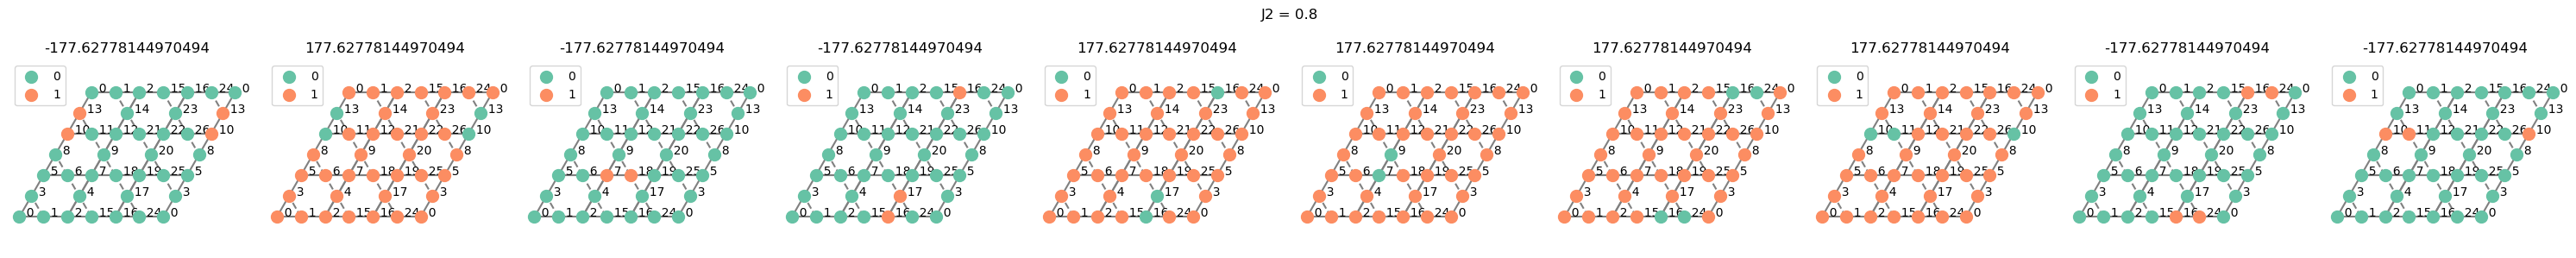

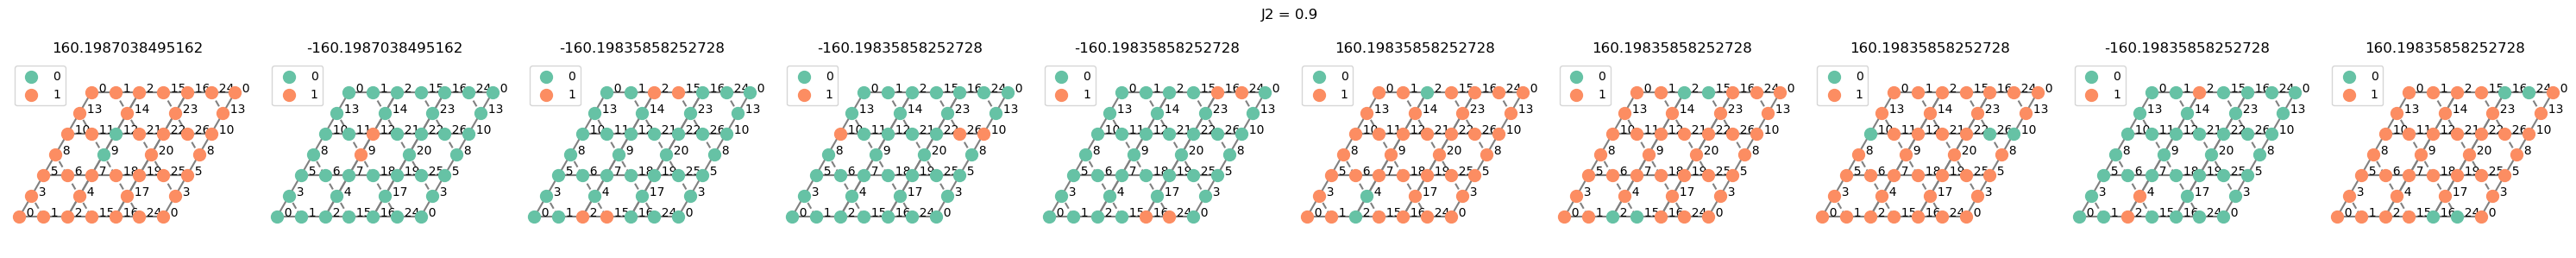

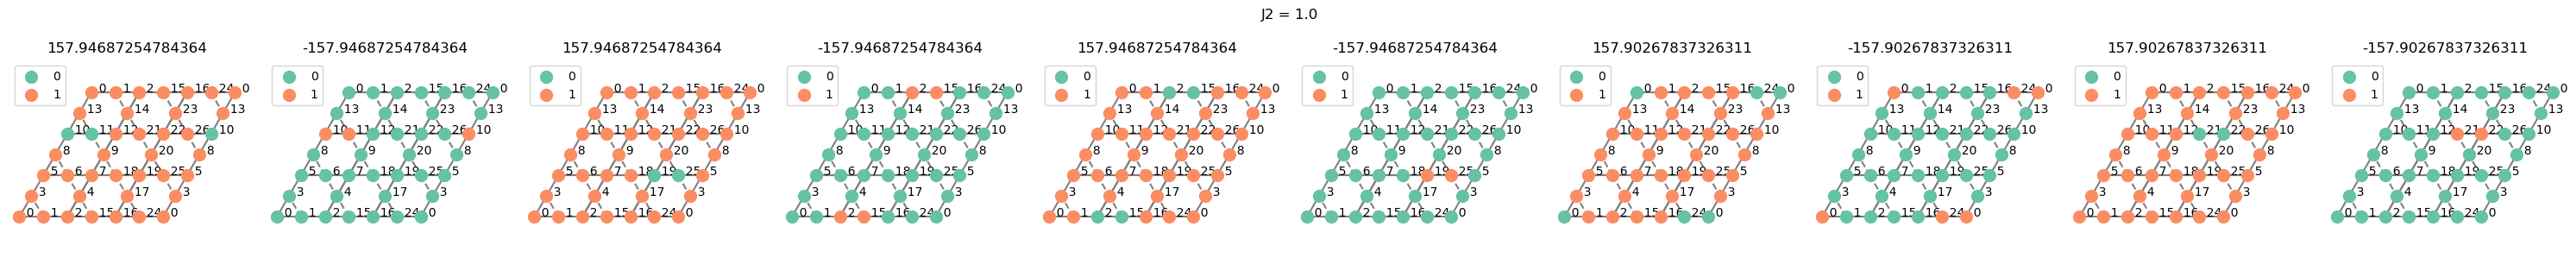

In [44]:
lattice_name = 'KagomeLattice3x3'
signal = "amplitude_median_bin"

for J2, row in (
    series_df.sort_index(level="J2")
    .xs((lattice_name, signal), level=("lattice_name", "signal_kind"))
    .iterrows()
):
    subsets = row["largest_terms"]
    coeffs = row["largest_coeffs"]

    fig = plot_subsets(subsets, coeffs, name_to_lat_and_sym[lattice_name][0])
    fig.suptitle(f"J2 = {J2}")
    fig.tight_layout()
    fig.show()



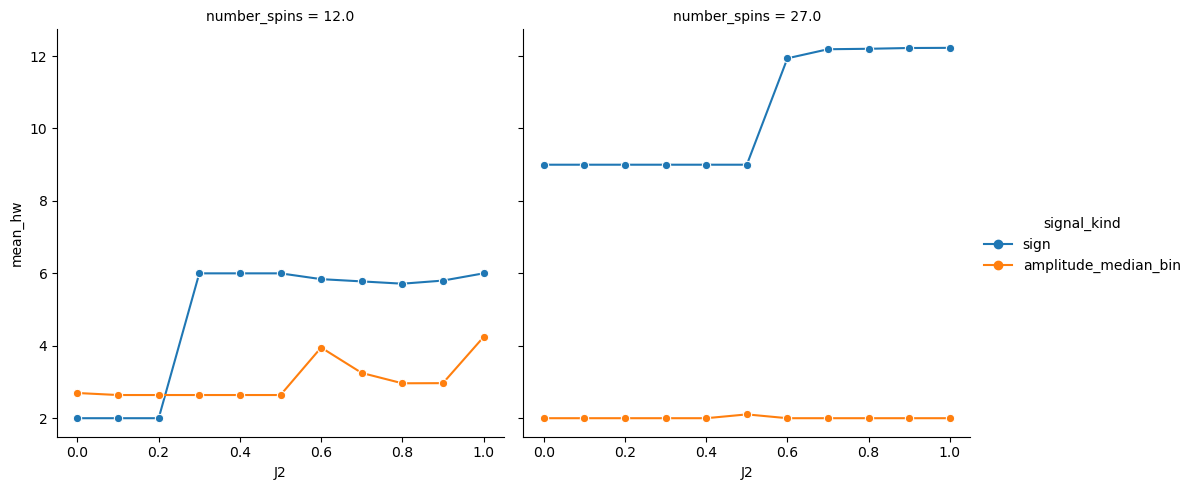

In [45]:
sns.relplot(
    series_df,
    x="J2",
    y="mean_hw",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


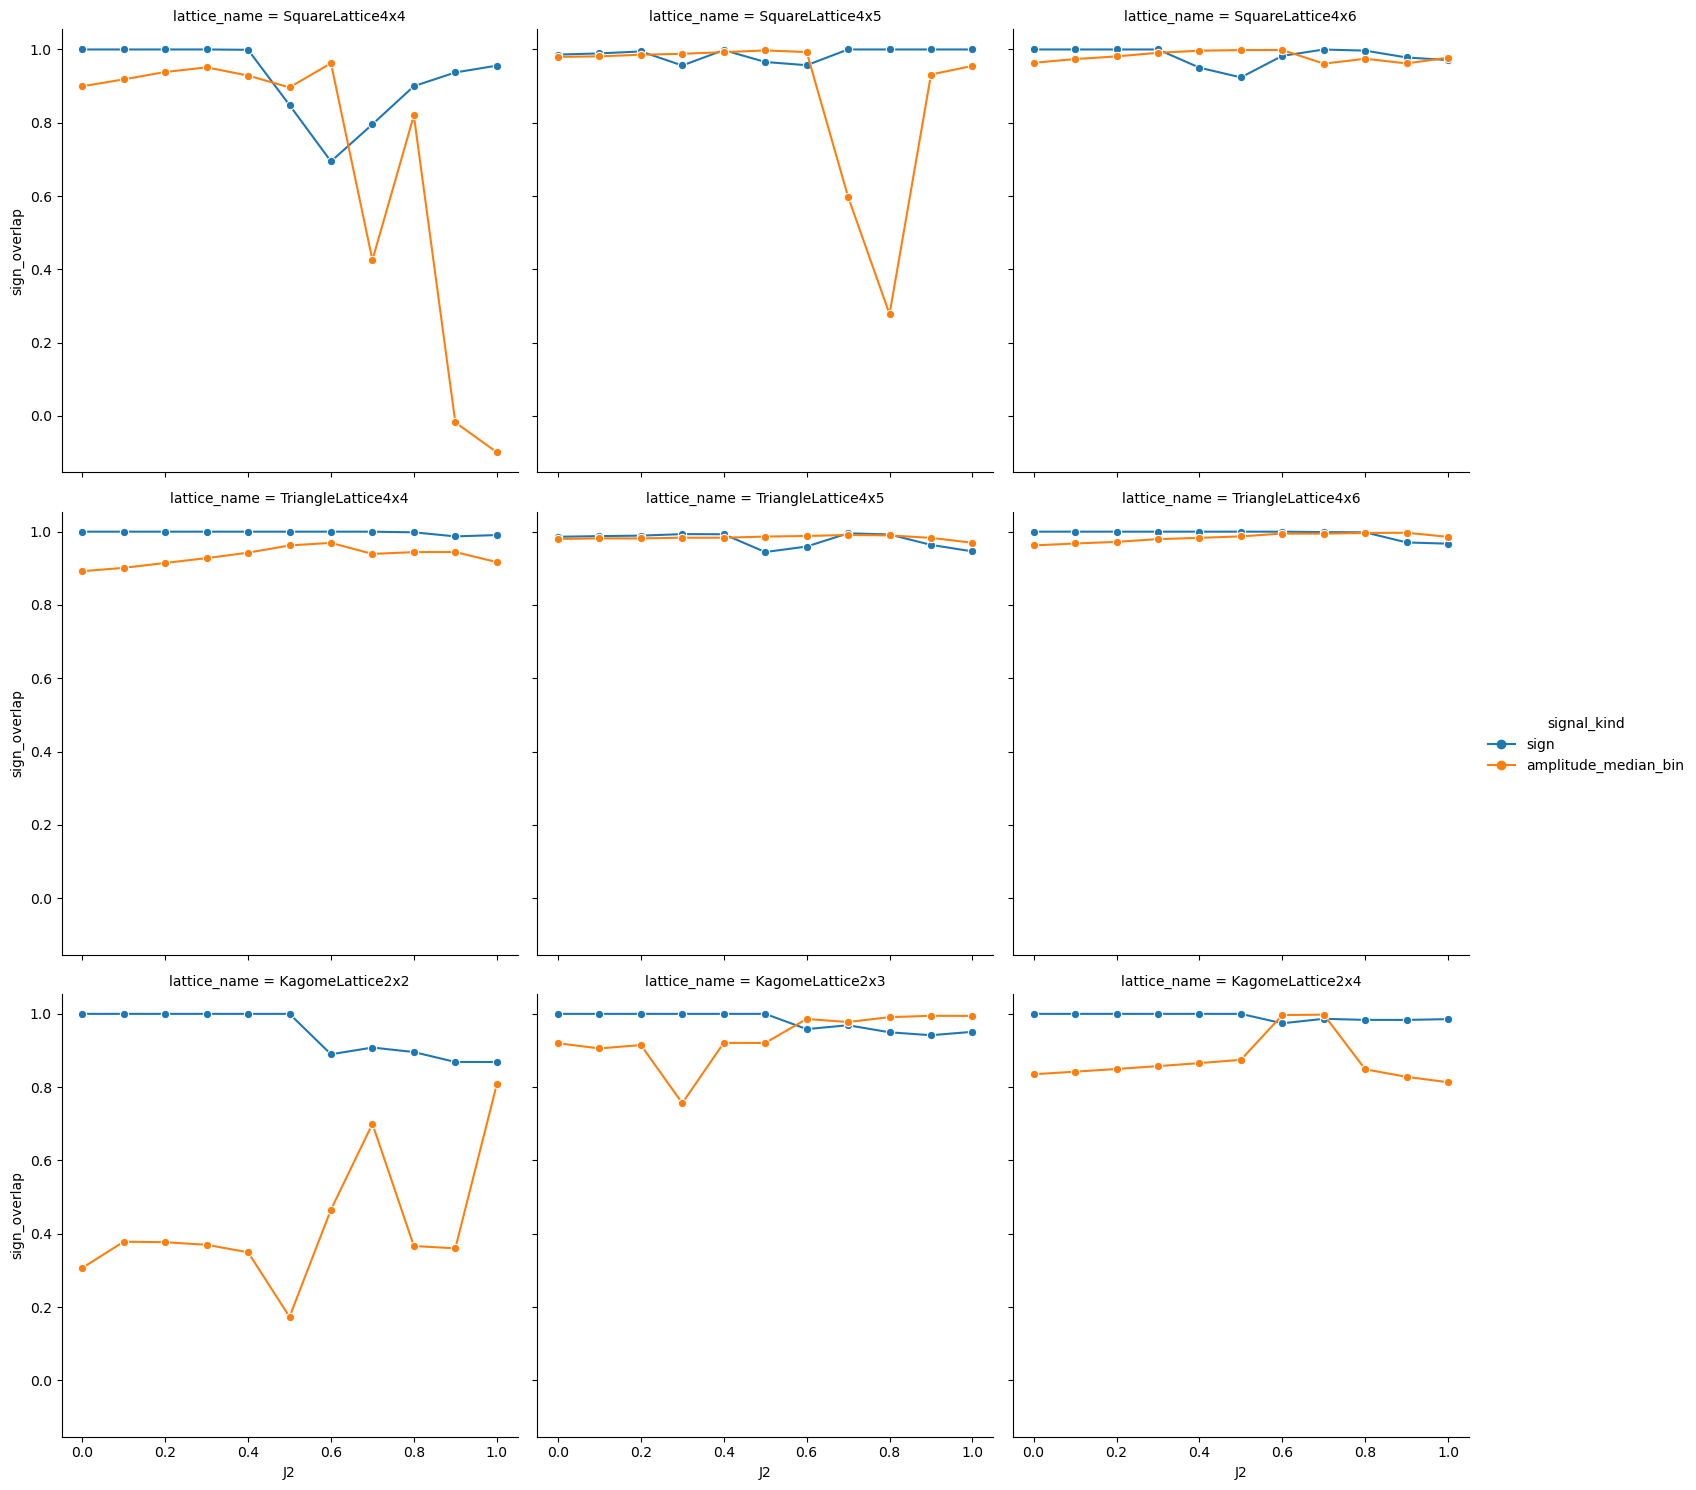

In [96]:
sns.relplot(
    series_df.reset_index(),
    x="J2",
    y="sign_overlap",
    hue="signal_kind",
    col="lattice_name",
    col_wrap=3,
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


In [97]:
complexity_ratio_df = (
    series_df.unstack(level="signal_kind")["hamming_weight"]
    .assign(ratio=lambda df: df["sign"] / df["amplitude_median_bin"])
    .reset_index()
)


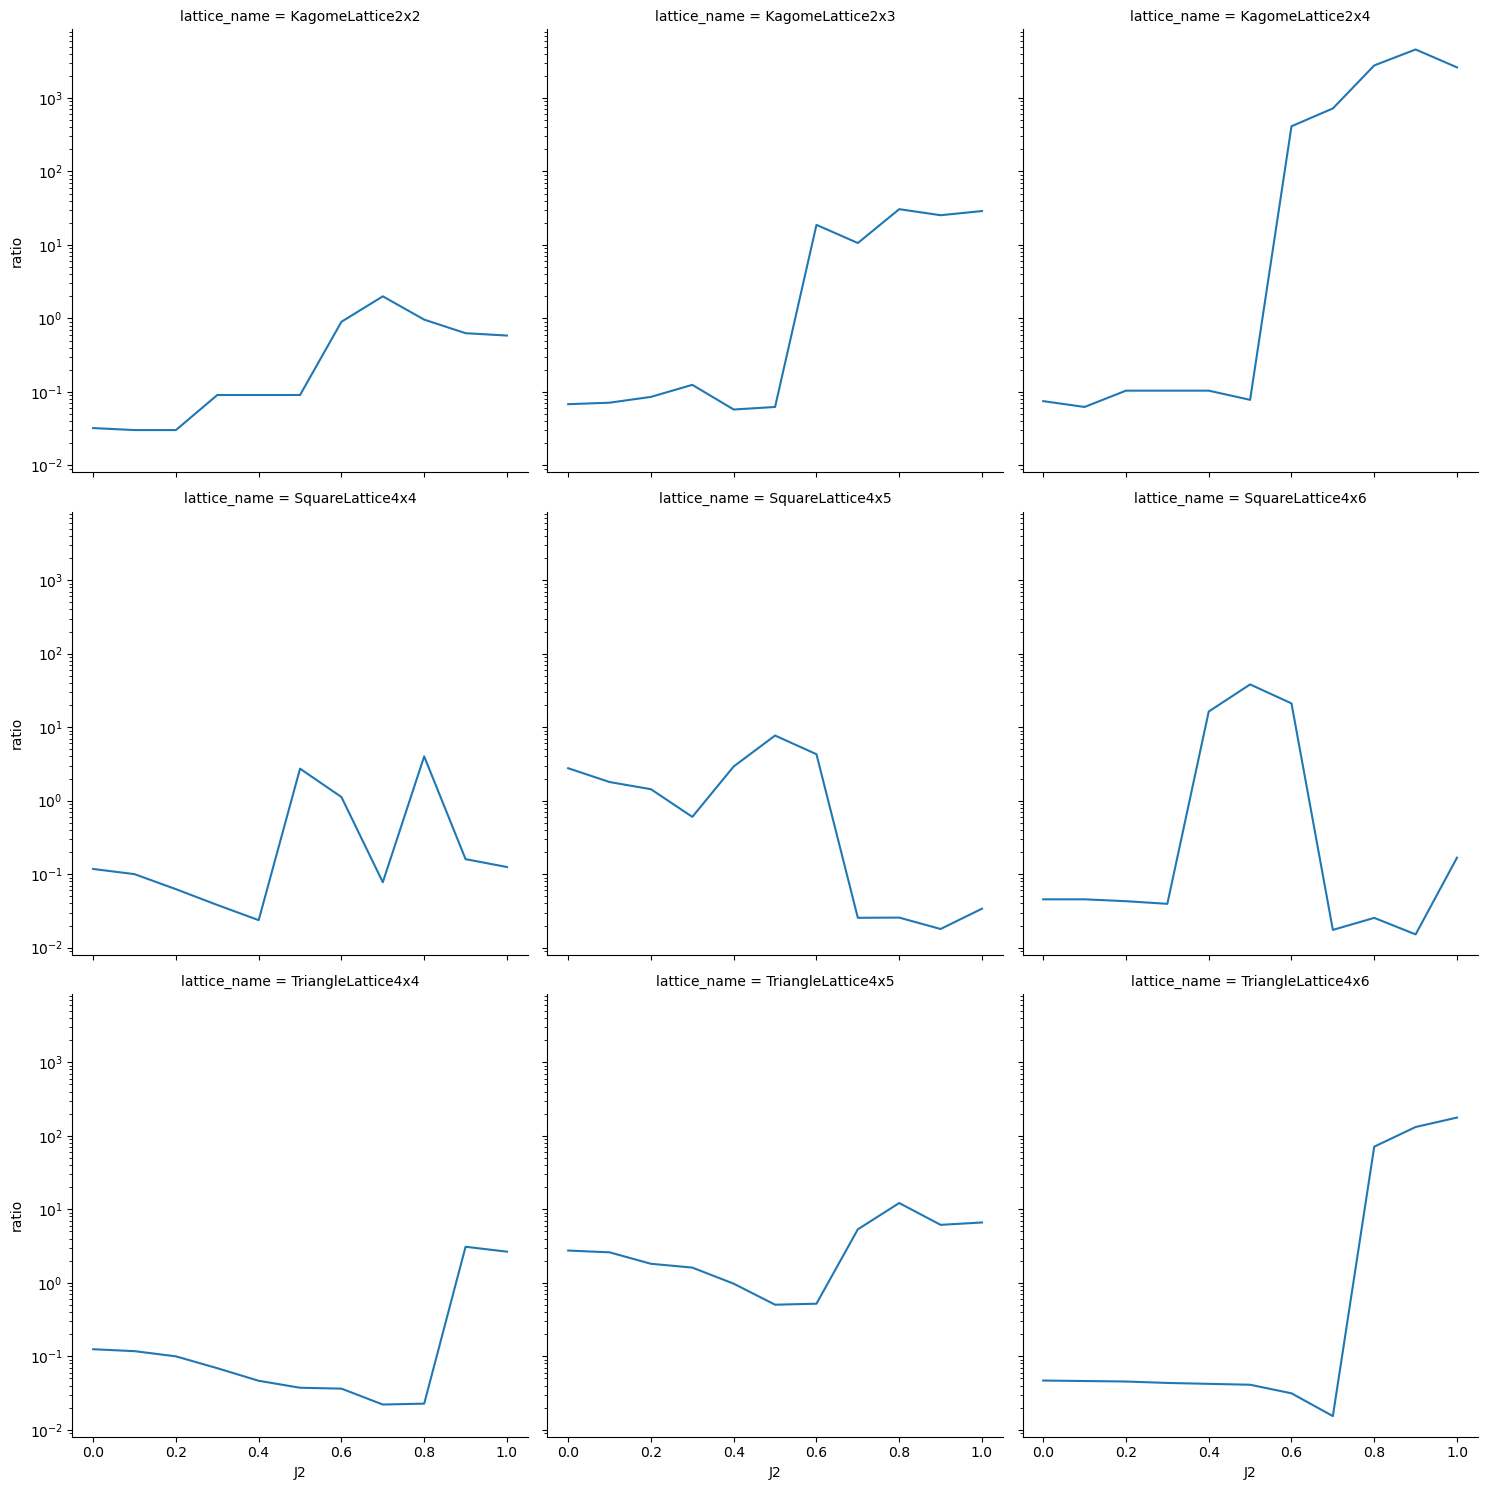

In [99]:
sns.relplot(complexity_ratio_df, x="J2", y="ratio", col="lattice_name", col_wrap=3,kind="line").set(yscale="log")


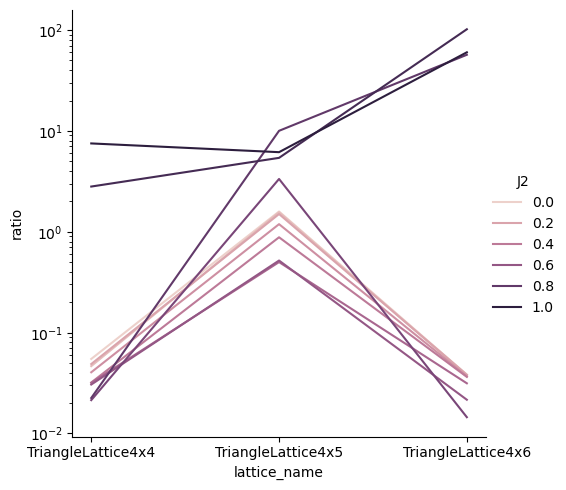

In [28]:
sns.relplot(
    complexity_ratio_df,
    x="lattice_name",
    y="ratio",
    hue="J2",
    kind="line",
).set(yscale="log")
